In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from custom_lib import quantum_circuit_ctx_generator, utils, verilog, fixed_point_handler

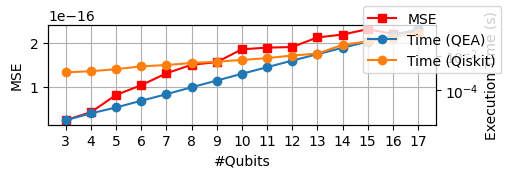

In [4]:
min_qbit_num=3
max_qbit_num=17
mse_folder_path='./result/mse_values/'
fidelity_folder_path='./result/fidelity_values/'

mse_qft = [
    2.448479837338149770e-17,
4.282598409419273933e-17,
8.197964392386091833e-17,
1.042731429492462941e-16,
1.313923190111059859e-16,
1.508464029583750321e-16,
1.568863265370719977e-16,
1.861592068427253303e-16,
1.899343624978194803e-16,
1.912312402690541037e-16,
2.131959530783996515e-16,
2.197269109760938236e-16,
2.320232994127112678e-16,
2.212232476530028320e-16,
2.276980623842023543e-16
]

time_qft = np.array([
    1904000,
    4692000,
    10264000,
    25060000,
    59368000,
    149172000,
    361112000,
    891972000,
    2125960000,
    5101204000,
    11896120000,
    27817380000,
    63637160000,
    145791348000,
    328379608000
])/10**(12)

time_qft_qiskit = [
    1.075822019577026534e-03,
1.250553131103515582e-03,
1.636877059936523533e-03,
2.381474971771240044e-03,
2.835190296173095616e-03,
3.729715347290038941e-03,
4.403955936431884488e-03,
5.556104183197021866e-03,
7.088408470153808281e-03,
9.973053932189940643e-03,
1.288059711456298814e-02,
4.139475822448730746e-02,
6.484020709991454579e-02,
1.088812065124511730e-01,
2.076092362403869629e-01
]

qubit_range = range(3, 18)
fig, ax = plt.subplots(1, 1, figsize=(5, 1.3))
ax2 = ax.twinx()
ax2.plot(qubit_range, time_qft, marker='o', label='Time (QEA)')
ax2.plot(qubit_range, time_qft_qiskit, marker='o', label = 'Time (Qiskit)')
ax2.set_ylabel('Execution Time (s)')
ax2.set_yscale('log')
ax.plot(qubit_range, mse_qft, marker='s', color = 'r', linestyle='-', label='MSE')
ax.set_ylabel('MSE')
ax.set(xlabel='#Qubits')
ax.set_xticks(qubit_range)
ax.set_xticklabels(qubit_range)
fig.legend()
ax.grid()
plt.savefig('./qft.svg', dpi=300)

In [35]:
min_qbit_num=3
max_qbit_num=17
min_quantum_circuit_idx=1
max_quantum_circuit_idx=19

qubit_range = np.arange(min_qbit_num, max_qbit_num + 1, 1)
quanv_range = np.arange(min_quantum_circuit_idx, max_quantum_circuit_idx + 1, 1)

hard_results = np.zeros((len(qubit_range), len(quanv_range)))
soft_results = np.zeros((len(qubit_range), len(quanv_range)))
final_results = np.zeros((len(qubit_range), len(quanv_range)))

i = 0
j = 0
for qubit_num_idx in qubit_range:
	saved_folder_name_hard = '../hardware/verilog/generated_sim_file/quantum_circuit_data_' + str(qubit_num_idx) + '_qubits/'
	j = 0
	for quantum_circuit_idx in quanv_range:
		saved_sub_folder_name_hard = saved_folder_name_hard + 'quanvolutional_' + str(quantum_circuit_idx)

		hard_data = utils.read_file(saved_sub_folder_name_hard + '/timestamps_' + str(qubit_num_idx) + '_qubits' + '_quanvolutional_' + str(quantum_circuit_idx) + '.txt')
		hard_res = float(hard_data[2].strip("").split(' ')[3][:-3])/1000000000
		# print('i: ', i, ' | j: ', j, ' | quantum_circuit_idx: ', quantum_circuit_idx, ' | qubit_num_idx: ', qubit_num_idx)
		hard_results[i][j] = hard_res

		soft_file_name = "../result/quanv/quanv" + str(quantum_circuit_idx) + ".txt"
		soft_data = utils.read_file(soft_file_name)
		soft_res = float(soft_data[qubit_num_idx-3])
		soft_results[i][j] = soft_res

		final_results[i][j] = soft_res/hard_res

		j = j + 1

	i = i + 1

final_results.shape

(15, 19)

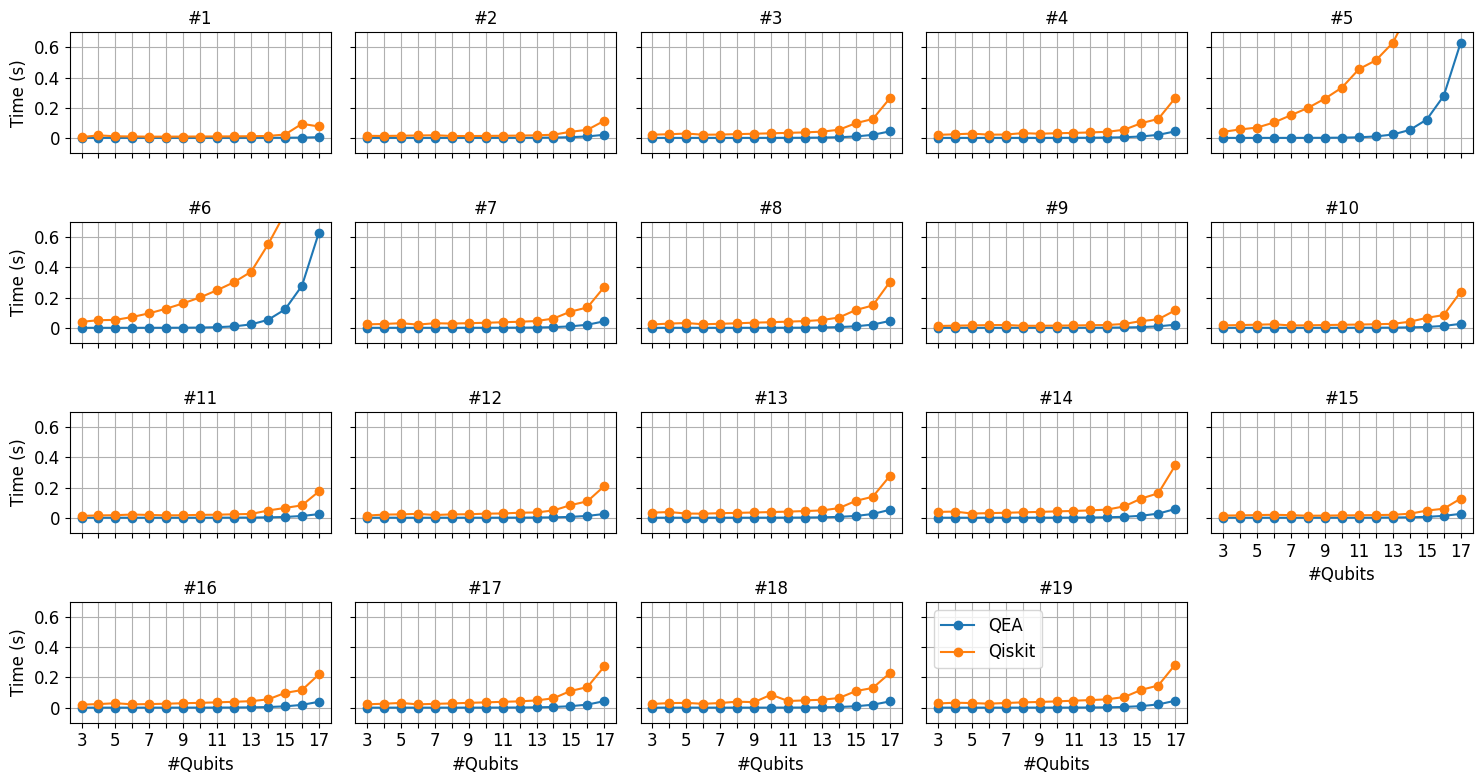

In [57]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(ncols=5, nrows= 4, figsize=(15, 8))
quanv_range = np.arange(min_quantum_circuit_idx, max_quantum_circuit_idx+1, 1)
qubit_num_range = np.arange(min_qbit_num, max_qbit_num+1, 1)


index = 1
for i in range(4):
    for j in range(5):
        ax = axs[i, j]
        if index == 20:  # Hide the last subplot (bottom-right)
            ax.axis('off')
            continue
        ax.plot(qubit_num_range, hard_results[:, index - 1], marker = 'o', label = 'QEA')
        ax.plot(qubit_num_range, soft_results[:, index - 1], marker = 'o', label = 'Qiskit')
        ax.set_title(f'#{index}')
        ax.set_ylim([-0.1, 0.7])
        ax.set_yticks([0, 0.2, 0.4, 0.6])
        ax.set_xticks(qubit_num_range)
        ax.grid(True)
        if j == 0:
            ax.set_ylabel('Time (s)')
            ax.set_yticklabels([0, 0.2, 0.4, 0.6])
        else:
            ax.set_yticklabels([])
        
        if index == 19:
            ax.legend(loc='upper left')
        if i == 3 or index == 15:
            ax.set_xticklabels(['3', '', '5', '', '7', '', '9', '', '11', '', '13', '', '15', '', '17'])
            ax.set_xlabel('#Qubits')
        else:
            ax.set_xticklabels([])
        index = index + 1
        if index > 20:
            break
plt.rcParams.update({
    'font.size': 12,        # Default font size for all text
    'axes.titlesize': 12,   # Font size for subplot titles
    'axes.labelsize': 12,   # Font size for axis labels
    'xtick.labelsize': 12,  # Font size for x-axis tick labels
    'ytick.labelsize': 12,  # Font size for y-axis tick labels
    'legend.fontsize': 12,  # Font size for legends
})

plt.tight_layout()
plt.savefig('../images/executiontim_quanv.svg', bbox_inches='tight')

In [51]:
def plot_quanv_error_measurement_line_charts(min_qbit_num=3, max_qbit_num=5, min_quantum_circuit_idx=1, max_quantum_circuit_idx=4, 
                     mse_folder_path='./result/mse_values/', fidelity_folder_path='./result/fidelity_values/'):

    qubit_range = np.arange(min_qbit_num, max_qbit_num+1, 1)
    quanv_range = np.arange(min_quantum_circuit_idx, max_quantum_circuit_idx+1, 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Use a colormap for better distinction
    cmap = plt.cm.get_cmap("tab20", len(qubit_range))  # "tab20" provides 20 distinct colors

    # MSE Line Plot
    for i, qubit_idx in enumerate(qubit_range):
        mse_results = np.loadtxt(mse_folder_path + f'{qubit_idx}_qubits.txt')
        axes[0].plot(quanv_range, mse_results[:len(quanv_range)], 
                     marker='o', linestyle='-', label=f'{qubit_idx} Qubit(s)', color=cmap(i))
    
    axes[0].set_title('MSE Measurement')
    axes[0].set_xlabel('Quanvolutional Parameter')
    axes[0].set_ylabel('Mean Squared Error')
    axes[0].set_yscale('log')  # Apply log scale for better visualization
    # axes[0].legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    axes[0].grid(True, alpha=0.3)

    # Fidelity Line Plot
    for i, qubit_idx in enumerate(qubit_range):
        fidelity_results = np.loadtxt(fidelity_folder_path + f'{qubit_idx}_qubits.txt')
        axes[1].plot(quanv_range, fidelity_results[:len(quanv_range)], 
                     marker='o', linestyle='-', label=f'{qubit_idx} Qubit(s)', color=cmap(i))
    
    axes[1].set_title('Fidelity Measurement')
    axes[1].set_xlabel('Quanvolutional Parameter')
    axes[1].set_ylabel('Fidelity')
    axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_quanv_ET_line_charts(min_qbit_num=3, max_qbit_num=17, min_quantum_circuit_idx=1, max_quantum_circuit_idx=19):
    qubit_range = np.arange(min_qbit_num, max_qbit_num + 1, 1)
    quanv_range = np.arange(min_quantum_circuit_idx, max_quantum_circuit_idx + 1, 1)

    hard_results = np.zeros((len(qubit_range), len(quanv_range)))
    soft_results = np.zeros((len(qubit_range), len(quanv_range)))
    final_results = np.zeros((len(qubit_range), len(quanv_range)))

    i = 0
    j = 0
    for qubit_num_idx in qubit_range:
        saved_folder_name_hard = '../hardware/verilog/generated_sim_file/quantum_circuit_data_' + str(qubit_num_idx) + '_qubits/'

        j = 0
        for quantum_circuit_idx in quanv_range:
            saved_sub_folder_name_hard = saved_folder_name_hard + 'quanvolutional_' + str(quantum_circuit_idx)

            hard_data = utils.read_file(saved_sub_folder_name_hard + '/timestamps_' + str(qubit_num_idx) + '_qubits' + '_quanvolutional_' + str(quantum_circuit_idx) + '.txt')
            hard_res = float(hard_data[2].strip("").split(' ')[3][:-3])/1000000000
            # print('i: ', i, ' | j: ', j, ' | quantum_circuit_idx: ', quantum_circuit_idx, ' | qubit_num_idx: ', qubit_num_idx)
            hard_results[i][j] = hard_res

            soft_file_name = "../result/quanv/quanv" + str(quantum_circuit_idx) + ".txt"
            soft_data = utils.read_file(soft_file_name)
            soft_res = float(soft_data[qubit_num_idx-3])
            soft_results[i][j] = soft_res

            final_results[i][j] = soft_res/hard_res

            print(f"====================== {qubit_num_idx} qbits, quanv{quantum_circuit_idx} circuit ======================")
            print(f"Hardware Result: {hard_res}(s) | Software Result: {soft_res}(s) | Compare: {soft_res/hard_res}")

            j = j + 1

        i = i + 1


def plot_qft_error_measurement_line_charts(min_qbit_num=3, max_qbit_num=5, min_quantum_circuit_idx=1, max_quantum_circuit_idx=4, 
                     mse_folder_path='./result/mse_values/', fidelity_folder_path='./result/fidelity_values/'):

    qubit_range = np.arange(min_qbit_num, max_qbit_num+1, 1)
    quanv_range = np.arange(min_quantum_circuit_idx, max_quantum_circuit_idx+1, 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Use a colormap for better distinction
    cmap = plt.cm.get_cmap("tab20", len(qubit_range))  # "tab20" provides 20 distinct colors

    # MSE Line Plot
    for i, qubit_idx in enumerate(qubit_range):
        mse_results = np.loadtxt(mse_folder_path + f'{qubit_idx}_qubits.txt')
        axes[0].plot(quanv_range, mse_results[:len(quanv_range)], 
                     marker='o', linestyle='-', label=f'{qubit_idx} Qubit(s)', color=cmap(i))
    
    axes[0].set_title('MSE Measurement')
    axes[0].set_xlabel('Quanvolutional Parameter')
    axes[0].set_ylabel('Mean Squared Error')
    axes[0].set_yscale('log')  # Apply log scale for better visualization
    # axes[0].legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    axes[0].grid(True, alpha=0.3)

    # Fidelity Line Plot
    for i, qubit_idx in enumerate(qubit_range):
        fidelity_results = np.loadtxt(fidelity_folder_path + f'{qubit_idx}_qubits.txt')
        axes[1].plot(quanv_range, fidelity_results[:len(quanv_range)], 
                     marker='o', linestyle='-', label=f'{qubit_idx} Qubit(s)', color=cmap(i))
    
    axes[1].set_title('Fidelity Measurement')
    axes[1].set_xlabel('Quanvolutional Parameter')
    axes[1].set_ylabel('Fidelity')
    axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_QFT_ET_line_charts(min_qbit_num=3, max_qbit_num=17):
    qubit_range = np.arange(min_qbit_num, max_qbit_num + 1, 1)

    hard_results = np.zeros(len(qubit_range))
    soft_results = np.zeros(len(qubit_range))
    final_results = np.zeros(len(qubit_range))

    i = 0
    for qubit_num_idx in qubit_range:
        saved_folder_name_hard = '../hardware/verilog/generated_sim_file/QFT/quantum_circuit_data_' + str(qubit_num_idx) + '_qubits/'

        hard_data = utils.read_file(saved_folder_name_hard + '/timestamps_qft' + str(qubit_num_idx) + '_qubits.txt')
        hard_res = float(hard_data[2].strip("").split(' ')[3][:-3])/1000000000
        hard_results[i] = hard_res

        soft_file_name = "../result/quanv/quanv.txt"
        soft_data = utils.read_file(soft_file_name)
        soft_res = float(soft_data[qubit_num_idx-3])
        soft_results[i] = soft_res

        final_results[i] = soft_res/hard_res

        print(f"====================== QFT {qubit_num_idx} qbits circuit ======================")
        print(f"Hardware Result: {hard_res}(s) | Software Result: {soft_res}(s) | Compare: {soft_res/hard_res}")

        i = i + 1

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(qubit_range, hard_results, marker='o', linestyle='-', label='Hardware Execution Time', color='r')
    plt.plot(qubit_range, soft_results, marker='s', linestyle='--', label='Software Execution Time', color='b')
    
    plt.xlabel('Qubit Count')
    plt.ylabel('Execution Time (s)')
    plt.title('QFT Execution Time: Hardware vs. Software')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [22]:
min_qbit_num = 3
max_qbit_num = 17
min_quantum_circuit_idx = 1
max_quantum_circuit_idx = 19

plot_ET_line_charts(min_qbit_num=min_qbit_num, 
                    max_qbit_num=max_qbit_num, 
                    min_quantum_circuit_idx=min_quantum_circuit_idx, 
                    max_quantum_circuit_idx = max_quantum_circuit_idx, 
                    mse_folder_path='./result/mse_values/', 
                    fidelity_folder_path='./result/fidelity_values/')

(15, 19)
====================== 3 qbits, quanv1 circuit ======================
Hardware Result: 6.52e-07(s) | Software Result: 5.169494867324829(s) | Compare: 7928673.1093939105
====================== 3 qbits, quanv2 circuit ======================
Hardware Result: 8.6e-07(s) | Software Result: 0.013569355010986328(s) | Compare: 15778.31978021666
====================== 3 qbits, quanv3 circuit ======================
Hardware Result: 1.716e-06(s) | Software Result: 0.021537303924560547(s) | Compare: 12550.876412914073
====================== 3 qbits, quanv4 circuit ======================
Hardware Result: 1.716e-06(s) | Software Result: 0.020219802856445312(s) | Compare: 11783.101897695404
====================== 3 qbits, quanv5 circuit ======================
Hardware Result: 3.552e-06(s) | Software Result: 0.04025840759277344(s) | Compare: 11334.011146614142
====================== 3 qbits, quanv6 circuit ======================
Hardware Result: 3.768e-06(s) | Software Result: 0.0396146774291

C:\Users\Hoai Luan\AppData\Local\Temp\ipykernel_38100\533375061.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(qubit_range))  # "tab20" provides 20 distinct colors


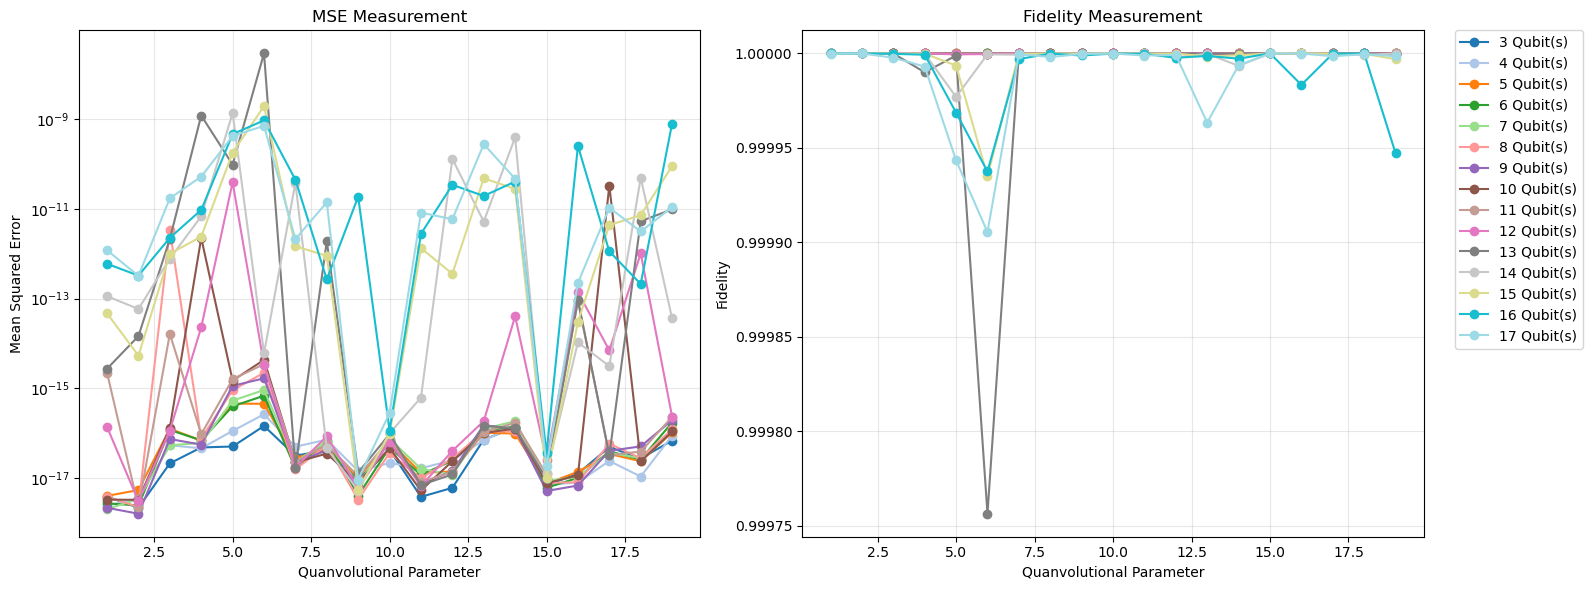

: 

In [ ]:
min_qbit_num = 3
max_qbit_num = 17
min_quantum_circuit_idx = 1
max_quantum_circuit_idx = 19

quantum_circuit_idx_range = np.arange(min_quantum_circuit_idx, max_quantum_circuit_idx+1, 1)
qubit_num_idx_range = np.arange(min_qbit_num, max_qbit_num+1, 1)

plot_error_measurement_line_charts(min_qbit_num=min_qbit_num, 
                 max_qbit_num=max_qbit_num, 
                 min_quantum_circuit_idx=min_quantum_circuit_idx, 
                 max_quantum_circuit_idx = max_quantum_circuit_idx, 
                 mse_folder_path='./result/mse_values/', 
                 fidelity_folder_path='./result/fidelity_values/')